# Retrieval Optimization

In [34]:
### NEXT TIME? https://www.coursera.org/projects/building-agentic-rag-with-llamaindex or https://www.coursera.org/projects/practical-multi-ai-agents-and-advanced-use-cases-with-crewai

In [1]:
!pip install netron onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 232.5 kB/s eta 0:00:00 kB/s eta 0:00:01:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 263.7 kB/s eta 0:00:000:00:02m eta 0:00:03

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


## SetUp

### How I downloaded Everything

In [ ]:
import tarfile
import os

# Set path
home_dir = os.path.expanduser("~")
output_tar = os.path.join(home_dir, "download.tar.gz")

# Optional: folders to exclude (relative to home)
exclude_dirs = [".ipynb_checkpoints", "models"]

def should_exclude(path):
    for pattern in exclude_dirs:
        if f"/{pattern}/" in path or path.endswith(f"/{pattern}") or f"/{pattern}" in path:
            return True
    return False

with tarfile.open(output_tar, "w:gz") as tar:
    for root, dirs, files in os.walk(home_dir):
        rel_root = os.path.relpath(root, home_dir)
        # Skip excluded directories
        if should_exclude(f"/{rel_root}"):
            continue

        for file in files:
            full_path = os.path.join(root, file)
            rel_path = os.path.relpath(full_path, home_dir)

            if should_exclude(f"/{rel_path}"):
                continue

            print(f"Adding: {rel_path}")
            tar.add(full_path, arcname=rel_path)

print(f"\nTarball created at: {output_tar}")

### How I extracted Everything

In [ ]:
import tarfile
import os

# Get home directory and current working directory
home_dir = os.path.expanduser("~")
extract_to = os.getcwd() 
tar_path = os.path.join(extract_to, "download.tar.gz")
 # This is your current working directory in Jupyter

# Extract
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=extract_to)

print(f"\nExtracted contents of {tar_path} to {extract_to}")

### Show Working Directory

In [1]:
import os

def print_tree(start_path='.', indent=''):
    items = sorted(os.listdir(start_path))
    for index, name in enumerate(items):
        path = os.path.join(start_path, name)
        is_last = index == len(items) - 1
        branch = "└── " if is_last else "├── "
        print(indent + branch + name)
        if os.path.isdir(path):
            extension = "    " if is_last else "│   "
            print_tree(path, indent + extension)

print_tree(os.getcwd())

├── .ipynb_checkpoints
│   └── Merged_Lessons-checkpoint.ipynb
├── .keep
├── Appendix - Tips and Help
│   ├── .ipynb_checkpoints
│   │   └── Appendix - Tips and Help-checkpoint.ipynb
│   ├── Appendix - Tips and Help.ipynb
│   └── images
│       ├── feedback.png
│       ├── open-file-browser.png
│       ├── open-files.png
│       ├── options.png
│       ├── progress-bottom.png
│       ├── progress-upper.png
│       ├── upload-file-2.png
│       ├── upload-file-3.png
│       ├── upload-file.png
│       ├── upload-file2.png
│       └── utils-access.png
├── L1
│   ├── Lesson_1.ipynb
│   ├── helper.py
│   └── requirements.txt
├── L2
│   ├── Lesson_2.ipynb
│   ├── helper.py
│   └── requirements.txt
├── L3
│   ├── Lesson_3.ipynb
│   ├── helper.py
│   └── requirements.txt
├── L4
│   ├── Lesson_4.ipynb
│   └── requirements.txt
├── L5
│   ├── Lesson_5.ipynb
│   ├── helper.py
│   └── requirements.txt
├── L6
│   ├── Lesson_6.ipynb
│   ├── helper.py
│   └── requirements.txt
├── Merged_Lessons.ipynb

### Merge Notebooks

In [ ]:
import os
import nbformat

base_path = './work'
output_notebook = os.path.join(base_path, "Merged_Lessons.ipynb")

# Create a new notebook
merged_nb = nbformat.v4.new_notebook()
merged_nb.cells = []

# Loop over L1 to L6 folders
for i in range(1, 7):
    lesson_dir = os.path.join(base_path, f"L{i}")
    lesson_file = os.path.join(lesson_dir, f"Lesson_{i}.ipynb")

    if not os.path.exists(lesson_file):
        print(f"Not found: {lesson_file}")
        continue

    with open(lesson_file, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    # Insert a markdown separator
    separator = nbformat.v4.new_markdown_cell(f"## ---- Lesson {i} ----")
    merged_nb.cells.append(separator)

    # Append all cells from that notebook
    merged_nb.cells.extend(nb.cells)
    print(f"Merged: Lesson_{i}.ipynb")

# Save merged notebook
with open(output_notebook, 'w', encoding='utf-8') as f:
    nbformat.write(merged_nb, f)

print(f"\nMerged notebook saved as: {output_notebook}")

### Check these um...brilliant...helpers.py, please let them be the same

In [8]:
import os
import hashlib
from difflib import unified_diff

def find_files(target_name):
    matches = []
    for root, _, files in os.walk("."):
        if target_name in files:
            matches.append(os.path.join(root, target_name))
    return matches

def hash_and_load(paths):
    contents = {}
    hashes = {}
    for path in paths:
        with open(path, 'r', encoding='utf-8') as f:
            content = f.read()
            contents[path] = content
            hashes[path] = hashlib.sha256(content.encode()).hexdigest()
    return contents, hashes

def compare_files(label, contents, hashes):
    print(f"\nComparing {label} files:\n")
    paths = list(contents.keys())
    for i in range(len(paths)):
        for j in range(i + 1, len(paths)):
            p1, p2 = paths[i], paths[j]
            if hashes[p1] == hashes[p2]:
                print(f"[IDENTICAL] {p1} == {p2}")
            else:
                print(f"[DIFFERENT] {p1} != {p2}")
                diff = unified_diff(
                    contents[p1].splitlines(),
                    contents[p2].splitlines(),
                    fromfile=p1,
                    tofile=p2,
                    lineterm=''
                )
                for line in diff:
                    print(line)
                print("\n" + "-"*60 + "\n")

# Find and compare helper.py
helper_paths = find_files("helper.py")
helper_contents, helper_hashes = hash_and_load(helper_paths)
compare_files("helper.py", helper_contents, helper_hashes)

# Find and compare requirements.txt
req_paths = find_files("requirements.txt")
req_contents, req_hashes = hash_and_load(req_paths)
compare_files("requirements.txt", req_contents, req_hashes)



Comparing helper.py files:

[IDENTICAL] ./helper.py == ./L1/helper.py
[DIFFERENT] ./helper.py != ./L2/helper.py
--- ./helper.py
+++ ./L2/helper.py
@@ -1,11 +1,16 @@
 # Add your utilities or helper functions to this file.
 
 import os
+
 from dotenv import load_dotenv, find_dotenv
 
-# these expect to find a .env file at the directory above the lesson.                                                                                                                     # the format for that file is (without the comment)                                                                                                                                       #API_KEYNAME=AStringThatIsTheLongAPIKeyFromSomeService                                                                                                                                     
+
+# these expect to find a .env file at the directory above the lesson.
+# the format for that file is (without the comment)
+# #API_KEYNAME=AStringThatIs

These are all just trivially different all just API calls to their icky internal version of GPT. Glad they have all of these different requirements to look over. 

In [9]:
import os
import shutil

lesson_dirs = ["L1", "L2", "L3", "L4", "L5", "L6"]
central_target = "requirements.txt"

# Step 1: Copy one version into the working directory (if not already there)
for lesson in lesson_dirs:
    lesson_req = os.path.join(lesson, "requirements.txt")
    if os.path.exists(lesson_req):
        if not os.path.exists(central_target):
            shutil.copyfile(lesson_req, central_target)
            print(f"Copied {lesson_req} → {central_target}")
        break  # only need one good copy

# Step 2: Remove the children
for lesson in lesson_dirs:
    path = os.path.join(lesson, "requirements.txt")
    if os.path.exists(path):
        os.remove(path)
        print(f"Removed: {path}")


Removed: L1/requirements.txt
Removed: L2/requirements.txt
Removed: L3/requirements.txt
Removed: L4/requirements.txt
Removed: L5/requirements.txt
Removed: L6/requirements.txt


In [10]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cpu
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.4/190.4 MB 6.3 MB/s eta 0:00:00m eta 0:00:010:00:02
  Using cached safetensors-0.5.3-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.8 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 1.4 MB/s eta 0:00:001.4 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 1.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 1.2 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 1.1 MB/s eta 0:00:000:00:01m eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1

## ---- Lesson 1 ----

## L1: Embedding Models

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

### Always a great start to a lecture

In [1]:
import warnings
warnings.filterwarnings('ignore')

A simple model download

#### Code Block:

In [2]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")
model

tokenized_data = model.tokenize(["walker walked a long walk"])
tokenized_data

{'input_ids': tensor([[ 101, 5232, 2939, 1037, 2146, 3328,  102]]),
 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0]]),
 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}

#### Question: What are the subword tokens produced by the tokenizer for the sentence "walker walked a long walk", and how do they correspond to the original words?

When the tokenizer processes the sentence "walker walked a long walk", it first breaks the sentence into smaller units called subword tokens. These tokens are selected from a fixed vocabulary that the model was trained with. Instead of splitting strictly on spaces, the tokenizer uses a technique such as WordPiece or Byte-Pair Encoding (BPE) to segment words into commonly occurring subunits.

For example, the word "walker" might be split into two tokens: "walk" and "##er". The prefix "##" indicates that the token continues a previous word segment. Similarly, "walked" might become "walk" and "##ed". These subwords allow the model to generalize across different forms of a root word while still capturing morphological differences.

So the sentence:

$$
\text{"walker walked a long walk"}
$$

might be tokenized into:

$$
\text{"[CLS]" "walk" "\#\#er" "walk" "\#\#ed" "a" "long" "walk""[SEP]"}
$$

Each token corresponds to an index in the model's vocabulary, and these indices are what actually get passed to the model as `input_ids`.

This subword tokenization is important because it balances vocabulary size and expressiveness, enabling the model to process rare or unseen words by decomposing them into familiar parts.


#### Question: How do we understand these output? 

This output is the result of tokenizing the sentence "walker walked a long walk" using a transformer-compatible tokenizer. It provides three key tensors that represent the model-ready input.

The `input_ids` tensor:

$$
\text{input\_ids} = [101,\ 5232,\ 2939,\ 1037,\ 2146,\ 3328,\ 102]
$$

These are the token IDs corresponding to each subword in the sentence. The numbers are indices in the model's vocabulary. The first token `101` is `[CLS]` (classification token), and the last token `102` is `[SEP]` (separator token). The other values correspond to the subword tokens: `"walk"`, `"##er"`, `"walk"`, `"##ed"`, `"a"`, `"long"`, `"walk"` — though exact mappings depend on the model’s vocabulary.

The `token_type_ids` tensor:

$$
\text{token\_type\_ids} = [0,\ 0,\ 0,\ 0,\ 0,\ 0,\ 0]
$$

This identifies which segment each token belongs to. In sentence-pair tasks (like question answering), values of 0 and 1 distinguish the first and second sentences. Here, since we only have one sentence, all values are 0.

The `attention_mask` tensor:

$$
\text{attention\_mask} = [1,\ 1,\ 1,\ 1,\ 1,\ 1,\ 1]
$$

This tells the model which tokens are actual content (1) and which are just padding (0). Since this sentence is short and doesn't require padding, all tokens are marked with 1.

Together, these tensors define the structured numerical representation of the sentence, suitable for input into a transformer model like `all-MiniLM-L6-v2`.


#### Question: Basically what are the parts of a transformer and how does it handle tokenizated words that were not seen during the model’s training (i.e., out-of-vocabulary words)?

A transformer is a deep learning architecture designed to process sequences of data, such as language. It is composed of two major parts: the encoder and the decoder. In models like BERT or SentenceTransformers, only the encoder is used. Each encoder layer consists of two main subcomponents: multi-head self-attention and a position-wise feed-forward network. These layers are wrapped in residual connections and layer normalization to help with stable training and deeper stacking.

The self-attention mechanism is the core innovation of the transformer. It allows each token in a sentence to consider the other tokens when forming its representation. This means the model can capture context, syntax, and long-range dependencies all at once. The feed-forward network then applies transformations independently to each token's contextual embedding. Positional encoding is added to the input to provide the model with information about the order of the tokens, since transformers do not have recurrence or convolution.

Regarding out-of-vocabulary words, tokenization in transformer models avoids this problem through the use of subword units. Instead of assigning a unique token to every word, the tokenizer splits words into subword segments using a method like Byte-Pair Encoding (BPE) or WordPiece. This means that even if the full word was not seen during training, the model can still process it by breaking it into smaller known pieces.

For example, the word "transformerss" might not exist in the vocabulary, but it could be tokenized into "transform", "##er", "##s". The model has seen these components during training and can form a representation based on their combination. This approach allows the model to handle novel or rare words gracefully, preserving generalization while keeping the vocabulary size manageable.

Thus, tokenization and the transformer architecture work together: the tokenizer ensures all inputs are represented in terms of known subunits, and the transformer layers extract meaning through context-sensitive encoding.


#### Summary:

Tokenization is the process of converting raw text into a structured form that a machine learning model can understand. In the context of the `SentenceTransformer` library, tokenization refers to transforming a sentence (like "walker walked a long walk") into a set of numerical inputs that can be fed into a transformer model such as `all-MiniLM-L6-v2`.

This process includes:

- Breaking the sentence into subword tokens (based on a vocabulary learned during training)
- Mapping each token to a unique integer ID
- Adding special tokens (like `[CLS]` and `[SEP]`)
- Creating attention masks to indicate which tokens should be processed and which are just padding

The output of `model.tokenize(["walker walked a long walk"])` is a dictionary containing multiple tensors, such as:

- `input_ids`: token IDs for the sentence
- `attention_mask`: 1s where tokens are real, 0s where tokens are padding
- `token_type_ids` (if applicable): segments for sentence-pair tasks

These tensors are the **inputs required by the transformer** to perform encoding. Without tokenization, the model would have no way to interpret raw characters or words.

Tokenization is important because it:

- Bridges the gap between human language and machine-readable format
- Ensures consistent representation of text across tasks
- Allows models to handle out-of-vocabulary words using subword decomposition (e.g., "walked" → "walk", "##ed")

In mathematical terms, tokenization converts a sentence $S = \text{"walker walked a long walk"}$ into a tuple of vectors:

$$
T = \left( \text{input\_ids}, \text{attention\_mask}, \text{token\_type\_ids} \right)
$$

These vectors can then be fed into the transformer to compute contextual embeddings.



#### Python Code Block

In [3]:
model.tokenizer.convert_ids_to_tokens(tokenized_data["input_ids"][0])

['[CLS]', 'walker', 'walked', 'a', 'long', 'walk', '[SEP]']

#### Question: What does this output tell us about this tokenizer?

The method `model.tokenizer.convert_ids_to_tokens(tokenized_data["input_ids"][0])` maps the numerical token IDs back to their corresponding string tokens in the model's vocabulary. This allows us to see exactly how the tokenizer has interpreted and segmented the input sentence.

For example, if the input was:

$$
\text{"walker walked a long walk"}
$$

and the token IDs were:

$$
[101,\ 5232,\ 2939,\ 1037,\ 2146,\ 3328,\ 102]
$$

then `convert_ids_to_tokens(...)` might return:

$$
["[CLS]",\ "walker",\ "walked",\ "a",\ "long",\ "walk",\ "[SEP]"]
$$

This tells us several things about the tokenizer:

1. Special tokens like `[CLS]` and `[SEP]` are added to frame the input. These help the model interpret sentence-level structure and boundaries.
2. Common words such as `"walker"` and `"walked"` are recognized as complete tokens. This means they are included as full entries in the tokenizer's vocabulary — likely because they appeared frequently during training.
3. The tokenizer does **not** decompose these words into subword components like `"walk"` and `"##er"` or `"##ed"` in this case, because such decomposition is only used when a word or form is not present in the vocabulary.
4. The presence of intact words indicates that the tokenizer uses a hybrid strategy: full words when possible, subwords when necessary.

This mapping from token IDs back to strings helps us verify how the model will "see" and process a sentence. It’s a critical diagnostic tool when you're trying to understand how the input text is encoded before passing it to the transformer.


#### Python Code Block

In [4]:
first_module = model._first_module()
first_module.auto_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 384, padding_idx=0)
    (position_embeddings): Embedding(512, 384)
    (token_type_embeddings): Embedding(2, 384)
    (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-5): 6 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
    

#### Question: How do we interpret this output? 

This output is the architecture of the transformer model being used — specifically, a version of BERT as implemented in the `sentence-transformers` framework. It breaks down into several key components, each with a distinct role in processing tokenized text into meaningful sentence embeddings.

The model begins with the **embedding layer**, which includes:

- $\text{word\_embeddings}$: A lookup table of size $30522 \times 384$, where each token ID is mapped to a 384-dimensional vector. The vocabulary size (30522) matches that of standard BERT tokenizers.
- $\text{position\_embeddings}$: Provides positional information for up to 512 tokens. Since transformers lack recurrence, this is how token order is encoded.
- $\text{token\_type\_embeddings}$: Indicates which sentence each token belongs to in sentence-pair tasks. This model supports two types (0 and 1).
- $\text{LayerNorm}$ and $\text{Dropout}$: Help stabilize and regularize training.

These embeddings are then passed through the **encoder**, which contains a stack of 6 identical layers, each called a `BertLayer`. Each layer consists of:

1. **Multi-head self-attention**:
   - Projects the token embeddings into queries, keys, and values using linear layers.
   - Computes attention scores so that each token can incorporate information from other tokens in the sequence.
   - Applies dropout and residual connections, followed by layer normalization.

2. **Intermediate feed-forward network**:
   - A two-layer dense network with a GELU activation.
   - Projects from 384 to 1536 dimensions and then back to 384.
   - This nonlinearity adds expressive capacity to the model.

After passing through all encoder layers, the model applies the **pooler**, which extracts a single fixed-size vector representation from the entire sequence. This is done by:

- Selecting the output embedding of the `[CLS]` token.
- Passing it through a dense layer and a `tanh` activation.

The result is a 384-dimensional embedding that summarizes the entire input sentence. This embedding can be used for downstream tasks such as semantic similarity, classification, or clustering. Every part of this structure contributes to transforming tokenized input into a rich, context-aware vector representation.


This breakdown of the `BertModel` shows the architecture used in models like `all-MiniLM-L6-v2`. Each component plays a critical role in transforming tokenized input into meaningful contextual embeddings. Here's a line-by-line interpretation with comments:

---

**BertModel**

This is the top-level transformer model, composed of the embedding layer, encoder stack, and optional pooler.

---

**(embeddings): BertEmbeddings**

- **(word_embeddings): Embedding(30522, 384, padding_idx=0)**  
  Maps token IDs to dense 384-dimensional vectors. The vocabulary size is 30522, matching the WordPiece vocabulary used during training.

- **(position_embeddings): Embedding(512, 384)**  
  Adds position information for up to 512 tokens. These are added to word embeddings so the model can differentiate order.

- **(token_type_embeddings): Embedding(2, 384)**  
  Indicates whether each token belongs to sentence A or sentence B in pair tasks (like question answering). For single-sentence tasks, all tokens are assigned type 0.

- **(LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)**  
  Normalizes the combined embeddings for numerical stability and convergence.

- **(dropout): Dropout(p=0.1, inplace=False)**  
  Helps prevent overfitting during training by randomly dropping 10% of the embedding values.

---

**(encoder): BertEncoder**

The main stack of transformer layers.

- **(layer): ModuleList(6 x BertLayer)**  
  There are 6 transformer layers, each with self-attention and a feed-forward subnetwork. These layers are applied sequentially.

Each **BertLayer** contains:

- **(attention): BertAttention**

  - **(self): BertSelfAttention**
    - **(query/key/value): Linear(384 → 384)**  
      Projects each token into queries, keys, and values. These determine how tokens attend to each other.
    - **(dropout): Dropout(p=0.1)**  
      Regularizes attention weights.

  - **(output): BertSelfOutput**
    - **(dense): Linear(384 → 384)**  
      Combines attention outputs from all heads into a single tensor.
    - **(LayerNorm):** and **(dropout):**  
      Add residual connection, normalization, and dropout.

- **(intermediate): BertIntermediate**
  - **(dense): Linear(384 → 1536)**  
    First step of the feed-forward network. Projects to a higher-dimensional space.
  - **(intermediate_act_fn): GELUActivation()**  
    Applies GELU nonlinearity, which is smoother than ReLU.

- **(output): BertOutput**
  - **(dense): Linear(1536 → 384)**  
    Projects the intermediate representation back to the original embedding size.
  - **(LayerNorm) and (dropout)**  
    Adds residual, normalization, and regularization again.

---

**(pooler): BertPooler**

Used to summarize the entire sequence into a single vector.

- **(dense): Linear(384 → 384)**  
  Projects the `[CLS]` token’s final representation.

- **(activation): Tanh()**  
  Applies a non-linear transformation. This final vector is often used for classification or similarity tasks.

---

In total, this model has:
- 6 transformer layers
- Embedding dimension of 384
- A vocabulary size of 30522
- A maximum sequence length of 512 tokens

The architecture is compact compared to full-size BERT (which has 12 layers and 768 hidden units), making it more efficient for sentence embeddings without sacrificing much performance.


In [25]:
import torch

# Step 1: Get the model
first_module = model._first_module()
core_model = first_module.auto_model

# Step 2: Use the tokenizer already attached to the SentenceTransformer
tokenizer = model.tokenizer
dummy_inputs = tokenizer("This is a dummy input", return_tensors="pt")

# Step 3: Export to ONNX
torch.onnx.export(
    core_model,
    (dummy_inputs["input_ids"], dummy_inputs["attention_mask"]),
    "bert_model.onnx",
    input_names=["input_ids", "attention_mask"],
    output_names=["last_hidden_state", "pooler_output"],
    dynamic_axes={
        "input_ids": {0: "batch_size", 1: "sequence_length"},
        "attention_mask": {0: "batch_size", 1: "sequence_length"},
        "last_hidden_state": {0: "batch_size", 1: "sequence_length"},
        "pooler_output": {0: "batch_size"}
    },
    opset_version=13
)

import netron
netron.start("bert_model.onnx")


Serving 'bert_model.onnx' at http://localhost:8080


('localhost', 8080)

![Netron](Images/Netron.png)

This visualization from Netron shows the **early embedding operations** of a BERT-style transformer model — specifically, how the model prepares its inputs before they enter the main encoder layers.

At the top of the graph, we see the `input_ids`, which are integer-encoded tokens produced by the tokenizer. These IDs are passed through a sequence of shape and slicing operations to align the input with the expected embedding matrix and model structure.

The three major embedding types are present:

- **Token (word) embeddings** — pulled from a `Gather` operation over a large embedding matrix of shape $(30522 \times 384)$, which maps token IDs to 384-dimensional vectors.
- **Position embeddings** — obtained from a `Gather` on a $(512 \times 384)$ matrix, where each position in the input (0 through 511) has its own learnable embedding.
- **Token type embeddings** — selected from a smaller $(2 \times 384)$ matrix indicating sentence A or B membership in pairwise tasks.

All three embedding types are:

1. **Unsqueezed and aligned** into the correct shape.
2. **Sliced or padded** to match the current input sequence.
3. **Added together** to produce the final input embeddings:  
   $$
   \text{embedding} = \text{word\_embed} + \text{position\_embed} + \text{segment\_embed}
   $$

After these additions, the combined tensor undergoes normalization and dropout (not shown in this segment), before being passed into the multi-layer encoder stack.

The lower part of the image shows operations like `ReduceMean`, which likely relate to mean pooling or intermediate tensor normalization used during export preparation, depending on the exact variant of BERT.

This section of the graph is foundational: it turns raw token IDs into **context-free vector representations** enriched with positional and structural information — the input to all deeper transformer computations.


### Input token embeddings

#### Question: For Transformers, what are **Queries**, **Keys** and **Values**?

In the transformer architecture, the input embeddings are transformed into **queries**, **keys**, and **values** during the self-attention computation. These three components are **not present in the initial embedding layer**, but rather are derived from the embeddings when they enter the **self-attention mechanism** of each transformer layer.

Here’s how they relate:

- The `BertEmbeddings` layer provides the **initial input vectors** of shape $(\text{batch\_size}, \text{sequence\_length}, \text{hidden\_size})$ — in this case, the hidden size is 384.
- These embeddings are passed into each transformer layer, where the **self-attention sublayer** projects them into **query**, **key**, and **value** vectors via learned linear transformations.

In a single attention head, for each token:

- The **query** vector represents the question: "What information am I looking for?"
- The **key** vector represents: "What information do I contain?"
- The **value** vector represents: "What information do I pass along if attended to?"

Mathematically, for each token's embedding vector $x$, the model computes:

$$
\text{Query} = xW^Q,\quad \text{Key} = xW^K,\quad \text{Value} = xW^V
$$

where $W^Q$, $W^K$, and $W^V$ are learned projection matrices of shape $(384 \times 384)$ in this model. These projections occur inside the `BertSelfAttention` module, which is **downstream of the embeddings**.

So while the `BertEmbeddings` module doesn't include queries and keys explicitly, it generates the **shared input** from which all three (query, key, value) vectors are later derived.

In summary:

- The **embedding layer** outputs one vector per token that encodes identity, position, and segment info.
- The **query/key/value projections** happen later in each transformer layer.
- These projections are what enable tokens to **attend** to each other in a context-sensitive way.


#### Python Code Block

In [5]:
embeddings = first_module.auto_model.embeddings
embeddings

BertEmbeddings(
  (word_embeddings): Embedding(30522, 384, padding_idx=0)
  (position_embeddings): Embedding(512, 384)
  (token_type_embeddings): Embedding(2, 384)
  (LayerNorm): LayerNorm((384,), eps=1e-12, elementwise_affine=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

#### Question: What is going on here? 

This output shows the `embeddings` submodule of the `BertModel`, which is responsible for converting input token IDs into dense vectors that can be processed by the transformer encoder.

The `BertEmbeddings` module combines three different kinds of embeddings:

- **(word_embeddings): Embedding(30522, 384)**  
  This is a lookup table with 30,522 rows (one for each token in the vocabulary) and 384 columns (the embedding size). Each input token ID is mapped to a 384-dimensional vector using this matrix. These vectors capture the identity of individual tokens without any context.

- **(position_embeddings): Embedding(512, 384)**  
  Since transformers have no inherent sense of order, positional information is added explicitly. This matrix assigns a unique 384-dimensional vector to each position index (from 0 to 511), so that the model knows the order of tokens in a sequence. These embeddings are added elementwise to the token embeddings.

- **(token_type_embeddings): Embedding(2, 384)**  
  These indicate which segment a token belongs to in tasks involving sentence pairs (e.g., question answering). There are only two possible values: 0 and 1. For single-sentence inputs, this is usually a vector of all zeros.

- **(LayerNorm): LayerNorm((384,), eps=1e-12)**  
  After the three embedding types are summed, layer normalization is applied to stabilize the representation. This normalizes the embedding values to have consistent mean and variance, which improves training dynamics.

- **(dropout): Dropout(p=0.1)**  
  A dropout layer randomly zeroes out 10% of the embedding values during training, helping prevent overfitting.

Together, these components transform raw token IDs into rich, position- and context-aware input vectors that the transformer layers can process. The full embedding for a token is:

$$
\text{embedding} = \text{word\_embedding} + \text{position\_embedding} + \text{token\_type\_embedding}
$$

This embedding is then passed to the first transformer layer in the encoder stack.


#### Python Code Block

In [7]:
import torch
import plotly.express as px

# Determine which device to use for computation
# Uses MPS for Apple Silicon if available, otherwise CUDA for GPU, or CPU as fallback
device = torch.device("cuda" if torch.has_mps else "cpu")

# Define two example sentences to compare
first_sentence = "vector search optimization"
second_sentence = "we learn to apply vector search optimization"

with torch.no_grad():  # Disable gradient tracking for inference (faster, less memory)

    # Tokenize both sentences using the model's tokenizer
    # This returns a dictionary with input_ids, attention_mask, etc.
    first_tokens = model.tokenize([first_sentence])
    second_tokens = model.tokenize([second_sentence])
    
    # Look up raw word embeddings directly (before position or segment embeddings)
    # These are the same vectors stored in embeddings.word_embeddings (the lookup table)
    # The token IDs are moved to the selected device (GPU/MPS/CPU)
    first_embeddings = embeddings.word_embeddings(
        first_tokens["input_ids"].to(device)
    )
    second_embeddings = embeddings.word_embeddings(
        second_tokens["input_ids"].to(device)
    )

#### Question, what will first_embeddings.shape, second_embeddings.shape return?

In [8]:
first_embeddings.shape, second_embeddings.shape

(torch.Size([1, 5, 384]), torch.Size([1, 9, 384]))

#### Question: How do we understand this output? 

This output:

$$
(\text{torch.Size([1, 5, 384])},\ \text{torch.Size([1, 9, 384])})
$$

represents the shapes of the raw word embeddings for the two tokenized input sentences.

Each shape is a 3-dimensional tensor with the format:

$$
(\text{batch\_size},\ \text{sequence\_length},\ \text{embedding\_dim})
$$

Breaking it down:

- The first sentence, `"vector search optimization"`, results in 5 tokens after tokenization (including `[CLS]` and `[SEP]`). Its embedding shape is:
  
  $$
  (1,\ 5,\ 384)
  $$

- The second sentence, `"we learn to apply vector search optimization"`, results in 9 tokens (also including `[CLS]` and `[SEP]`). Its embedding shape is:

  $$
  (1,\ 9,\ 384)
  $$

Here:

- **Batch size = 1**: because we processed one sentence at a time.
- **Sequence length = 5 or 9**: depending on how many tokens the tokenizer produced.
- **Embedding dimension = 384**: this is fixed by the model architecture (MiniLM uses 384-dimensional embeddings).

So this output confirms that each token is represented by a 384-dimensional vector, and the number of such vectors corresponds to the number of tokens in each sentence.


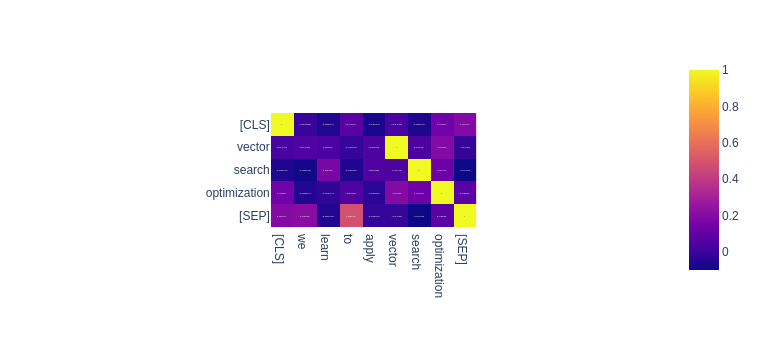

In [9]:
from sentence_transformers import util

distances = util.cos_sim(
    first_embeddings.squeeze(), 
    second_embeddings.squeeze()
).cpu().numpy() # Move the tensor to the CPU and convert to a NumPy array

px.imshow(
    distances, 
    x=model.tokenizer.convert_ids_to_tokens(
        second_tokens["input_ids"][0]
    ),
    y=model.tokenizer.convert_ids_to_tokens(
        first_tokens["input_ids"][0]
    ),
    text_auto=True,
)

#### Question: How do we intrepret this graph?

This heatmap visualizes the **cosine similarity** between the **raw word embeddings** of two sentences:

- First sentence (Y-axis): `"vector search optimization"`
- Second sentence (X-axis): `"we learn to apply vector search optimization"`

Each cell in the grid shows the cosine similarity between a token from the first sentence and a token from the second. A higher value (closer to 1, shown in yellow) means the two embeddings are more aligned in direction — suggesting stronger semantic similarity *according to the raw embedding space*.

### What You’re Seeing

- The diagonal of bright yellow boxes (value = 1.0) indicates **tokens matched to themselves**: `"vector"` to `"vector"`, `"search"` to `"search"`, and `"optimization"` to `"Optimization"`. These are identical tokens, so their embeddings are exactly the same.
  
- `[CLS]` and `[SEP]` also have perfect matches — these are fixed tokens, and their embeddings are constant and shared across all sentences, hence cosine similarity = 1.

- The off-diagonal values (darker shades) reflect how **similar unrelated tokens are**, like `"search"` vs `"we"` or `"optimization"` vs `"apply"`. These values are low or even slightly negative, indicating orthogonality or weak opposition in embedding space.

- Tokens like `"learn"` and `"apply"` have **slightly higher values** with `"search"` and `"optimization"` — this suggests that even in the raw (non-contextual) embedding space, there's some inherent semantic alignment due to training on natural language corpora.

### Why This Matters

This matrix reflects the **pre-contextualized similarity** between words. These embeddings come directly from the model’s `word_embeddings` table, before attention layers do any reasoning. It shows:

- How much information is already embedded in the pretrained lookup table.
- That common or related words are **positioned near each other** in the raw embedding space.
- But also that **without attention**, embeddings can’t resolve ambiguity or capture meaning in context — e.g., `"learn"` is treated uniformly regardless of surrounding words.

This visualization is a powerful baseline — and you’ll see more nuanced patterns when repeating this analysis **after the full transformer encoding**, where contextual meaning is injected.


### Visualizing the input embeddings

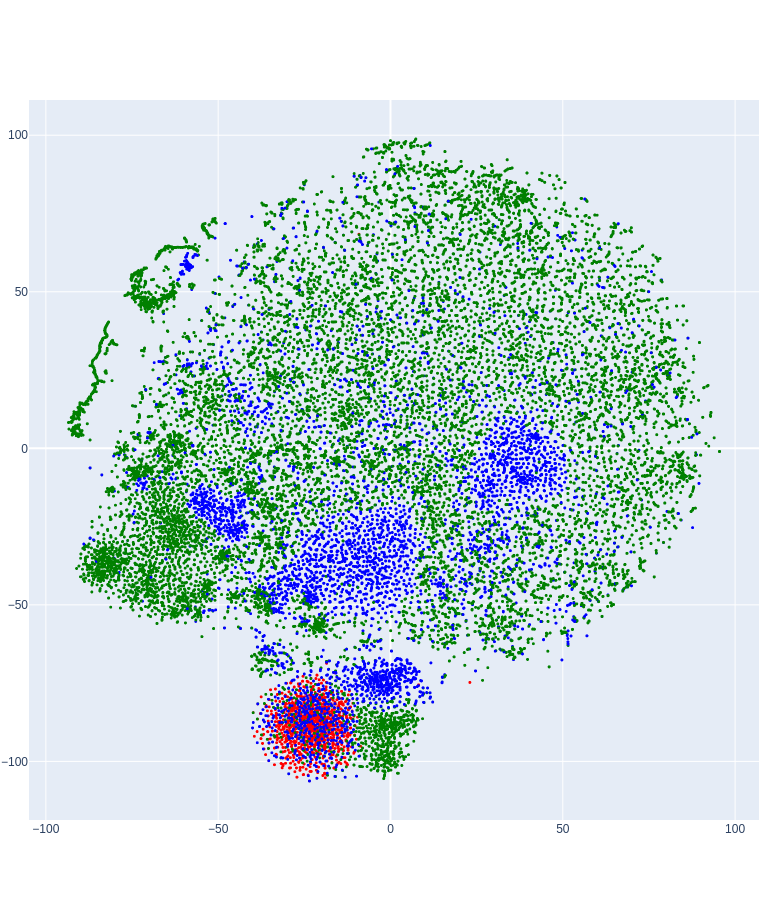

In [19]:
# Extract the full raw token embedding matrix from the model
# This matrix has shape (vocab_size, embedding_dim) = (30522, 384)
# It contains one embedding vector for every token in the model's vocabulary

# .weight \         get the actual embedding weight matrix (not called on any input)
# .detach() \       remove it from the computation graph so gradients are not tracked
# .cpu() \          move it to CPU memory from GPU (if needed)
# .numpy()          convert the tensor into a NumPy array for t-SNE and plotting

token_embeddings = first_module.auto_model \
    .embeddings \
    .word_embeddings \
    .weight \
    .detach() \
    .cpu() \
    .numpy()
token_embeddings.shape  # should return (30522, 384)


# Get the vocabulary dictionary: {token: index}
vocabulary = first_module.tokenizer.get_vocab()

# Sort the vocabulary by token index (ascending), 
# so we can match token order with the rows in token_embeddings
sorted_vocabulary = sorted(
    vocabulary.items(), 
    key=lambda x: x[1]  # sort by the index value
)

# Extract just the token strings in order
sorted_tokens = [token for token, _ in sorted_vocabulary]

# Preview: randomly sample 100 tokens from the sorted vocabulary
# (This isn't used downstream, just useful for debugging or spot checks)
import random
random.choices(sorted_tokens, k=100)


# Project the high-dimensional (384D) token embeddings into 2D using t-SNE
# - n_components=2: target dimensionality
# - metric="cosine": use cosine distance rather than Euclidean
# - random_state: ensures consistent layout across runs

# ------------------------------------------------------------------------------------
# What is t-SNE?
# ------------------------------------------------------------------------------------
# t-SNE (t-distributed Stochastic Neighbor Embedding) is a dimensionality reduction
# technique designed to visualize high-dimensional data in 2D or 3D space.
#
# In the context of language models, each token embedding lives in a high-dimensional
# space (e.g., 384 dimensions for MiniLM). These embeddings are hard to interpret
# directly, so we use t-SNE to project them down to 2 dimensions for visualization.
#
# Key characteristics of t-SNE:
# - Preserves local structure: tokens that are similar in high-dimensional space
#   tend to stay close in the 2D projection.
# - Nonlinear: the transformation does not preserve global distances or directions.
# - Useful for finding clusters, neighborhoods, and substructures in embedding spaces.
#
# Limitations:
# - Not suitable for preserving large-scale structure (e.g., absolute distances).
# - Sensitive to hyperparameters like perplexity and random seed.
# - Slow for very large datasets (but fine for vocab-level tasks like this).
#
# In this code, we apply t-SNE to the entire vocabulary's token embeddings to see how
# the model has organized language: special tokens, subwords, and common words each
# form visible patterns and regions in the resulting 2D scatter plot.
# ------------------------------------------------------------------------------------

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, metric="cosine", random_state=42)
tsne_embeddings_2d = tsne.fit_transform(token_embeddings)  # shape will be (30522, 2)

tsne_embeddings_2d.shape


# Assign a color to each token for visualization:
# - red for special tokens like [CLS], [SEP], [PAD], etc.
# - blue for subword tokens (starting with "##")
# - green for normal tokens
token_colors = []
for token in sorted_tokens:
    if token[0] == "[" and token[-1] == "]":
        token_colors.append("red")
    elif token.startswith("##"):
        token_colors.append("blue")
    else:
        token_colors.append("green")


# Create a Plotly scatter plot with color-coded tokens
import plotly.graph_objs as go

scatter = go.Scattergl(
    x=tsne_embeddings_2d[:, 0],            # x-coordinates from t-SNE
    y=tsne_embeddings_2d[:, 1],            # y-coordinates from t-SNE
    text=sorted_tokens,                    # token text for hover labels
    marker=dict(color=token_colors, size=3),  # color and size of each point
    mode="markers",
    name="Token embeddings"
)

# Set up a responsive Plotly figure with tight margins
fig = go.FigureWidget(
    data=[scatter],
    layout=dict(
        width=600,
        height=900,
        margin=dict(l=0, r=0)
    )
)

# Show the interactive plot
fig.show()


#### Question: What is going on with this image? 

This scatter plot is a 2D visualization of the **entire vocabulary of token embeddings** from a transformer model (like MiniLM), projected using **t-SNE**.

Each point represents one token in the model's vocabulary. The original embeddings live in a 384-dimensional space, but t-SNE has projected them into 2D while preserving local structure — so clusters of similar tokens in the original space are still close together here.

What the Colors Represent

- **Green points** are regular tokens — whole words that appear frequently in the training corpus.
- **Blue points** are **subword tokens**, which begin with `"##"`. These are suffixes or fragments used to handle rare or morphologically complex words. Clusters of blue often reflect morphological families.
- **Red points** are **special tokens** like `[CLS]`, `[SEP]`, `[MASK]`, `[PAD]`, etc. These are not real words but serve structural purposes during training and inference.

What the Clusters Show

- The **dense red cluster** in the bottom-center is a tight grouping of all the special tokens. These are likely initialized or trained differently and don't participate in the same semantic embedding space as real words.
  
- The **blue clusters** show where subwords have grouped. This reveals how the model has learned to position affixes and rare word fragments in ways that still preserve their utility and meaning. You'll often see `"##ing"`, `"##ly"`, `"##tion"`, etc., forming distinct groups.

- The **green region** covers the full vocabulary of base words. Words with similar usage, semantics, or context may appear close together — e.g., numbers, names, adjectives, or verbs often form loose neighborhoods.

Why This Matters

This visualization gives insight into the **structure of the model’s lexical knowledge** — even before any contextualization happens. It reveals that:

- The model has learned to organize language in meaningful geometric ways.
- Subword tokens are structurally separated, reflecting their role as linguistic fragments.
- Special tokens are clearly distinct, isolated in their own space.

In short, this plot shows how a transformer *thinks* about words at rest — before any sentence context or self-attention layers are applied.


## Output token embeddings

In [20]:
output_embedding = model.encode(["walker walked a long walk"])
output_embedding.shape

(1, 384)

In [21]:
output_token_embeddings = model.encode(
    ["walker walked a long walk"], 
    output_value="token_embeddings"
)
output_token_embeddings[0].shape

torch.Size([7, 384])

In [22]:
first_sentence = "vector search optimization"
second_sentence = "we learn to apply vector search optimization"

with torch.no_grad():
    first_tokens = model.tokenize([first_sentence])
    second_tokens = model.tokenize([second_sentence])
    
    first_embeddings = model.encode(
        [first_sentence], 
        output_value="token_embeddings"
    )
    second_embeddings = model.encode(
        [second_sentence], 
        output_value="token_embeddings"
    )

distances = util.cos_sim(
    first_embeddings[0], 
    second_embeddings[0]
)

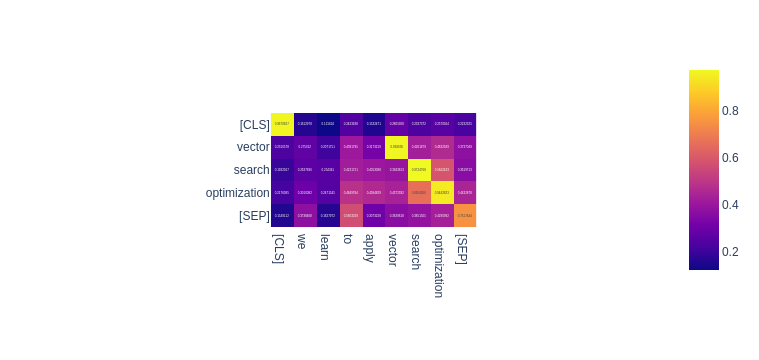

In [23]:
px.imshow(
    distances.cpu().numpy(),  # Move the tensor to CPU and convert to a NumPy array
    x=model.tokenizer.convert_ids_to_tokens(
        second_tokens["input_ids"][0]
    ),
    y=model.tokenizer.convert_ids_to_tokens(
        first_tokens["input_ids"][0]
    ),
    text_auto=True,
)

## ---- Lesson 2 ----

## L2: Role of the Tokenizers

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [25]:
training_data = [
    "walker walked a long walk",
]

### BPE - Byte-Pair Encoding

#### Question: What is an embedding model, how do transformers use them, what kinds are there, and why is it important? 

An embedding model is a function that maps discrete tokens such as words, subwords, or sentences into continuous vectors in a high-dimensional space. These vectors capture semantic or structural relationships between the tokens, allowing them to be processed mathematically by neural networks.

Transformers use embeddings at multiple stages. First, input token IDs are passed through an embedding layer that retrieves their corresponding vector representations. These vectors are then combined with position embeddings and segment embeddings to produce the initial input to the transformer encoder. As the model processes the sequence through its self-attention layers, these embeddings are updated to become context-sensitive — meaning they reflect the meaning of a token given its surrounding words.

There are different kinds of embedding models depending on what they encode:

1. Word embeddings: assign a fixed vector to each word regardless of context. Examples include word2vec and GloVe.

2. Subword embeddings: break rare or unknown words into smaller pieces, allowing coverage of virtually any input. These are common in modern transformer tokenizers.

3. Contextual embeddings: generate a different vector for a word depending on its usage. These are produced by transformer layers and form the backbone of models like BERT and GPT.

4. Sentence or document embeddings: produce a single vector representing an entire sequence. Models like Sentence-BERT or Universal Sentence Encoder fall into this category.

Embeddings are important because they convert symbolic language into a form that neural networks can work with. They provide a compact, learnable representation of linguistic structure, enabling models to measure similarity, support generalization, and transfer knowledge across tasks. In transformers, embeddings serve as both the entry point and the foundation for every downstream operation.


In [27]:
from tokenizers.trainers import BpeTrainer
from tokenizers.models import BPE
from tokenizers import Tokenizer
from tokenizers.pre_tokenizers import Whitespace

bpe_tokenizer = Tokenizer(BPE())
bpe_tokenizer.pre_tokenizer = Whitespace()

bpe_trainer = BpeTrainer(vocab_size=14)

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

In [28]:
bpe_tokenizer.train_from_iterator(training_data, bpe_trainer)

In [29]:
bpe_tokenizer.get_vocab()

{'wal': 11,
 'walk': 12,
 'walke': 13,
 'al': 10,
 'o': 7,
 'a': 0,
 'e': 2,
 'g': 3,
 'd': 1,
 'k': 4,
 'l': 5,
 'n': 6,
 'r': 8,
 'w': 9}

In [30]:
bpe_tokenizer.encode("walker walked a long walk").tokens

['walke', 'r', 'walke', 'd', 'a', 'l', 'o', 'n', 'g', 'walk']

In [31]:
bpe_tokenizer.encode("wlk").ids

[9, 5, 4]

In [32]:
bpe_tokenizer.encode("wlk").tokens

['w', 'l', 'k']

In [33]:
bpe_tokenizer.encode("she walked").tokens

['e', 'walke', 'd']

## WordPiece

In [ ]:
from real_wordpiece.trainer import RealWordPieceTrainer
from tokenizers.models import WordPiece

real_wordpiece_tokenizer = Tokenizer(WordPiece())
real_wordpiece_tokenizer.pre_tokenizer = Whitespace()

real_wordpiece_trainer = RealWordPieceTrainer(
    vocab_size=27,
)

In [ ]:
real_wordpiece_trainer.train_tokenizer(
    training_data, real_wordpiece_tokenizer
)
real_wordpiece_tokenizer.get_vocab()

In [ ]:
real_wordpiece_tokenizer.encode("walker walked a long walk").tokens

In [ ]:
real_wordpiece_tokenizer.encode("wlk").tokens

**Unknown Characters:**
The following line will produce an error because it contains unknown characters. Please uncomment the line and run it to see the error.

In [ ]:
#real_wordpiece_tokenizer.encode("she walked").tokens

## HuggingFace WordPiece and special tokens

In [ ]:
from tokenizers.trainers import WordPieceTrainer

unk_token = "[UNK]"

wordpiece_model = WordPiece(unk_token=unk_token)
wordpiece_tokenizer = Tokenizer(wordpiece_model)
wordpiece_tokenizer.pre_tokenizer = Whitespace()
wordpiece_trainer = WordPieceTrainer(
    vocab_size=28,
    special_tokens=[unk_token]
)

In [ ]:
wordpiece_tokenizer.train_from_iterator(
    training_data, 
    wordpiece_trainer
)
wordpiece_tokenizer.get_vocab()

In [ ]:
wordpiece_tokenizer.encode("walker walked a long walk").tokens

In [ ]:
wordpiece_tokenizer.encode("wlk").tokens

In [ ]:
wordpiece_tokenizer.encode("she walked").tokens

## Unigram

In [ ]:
from tokenizers.trainers import UnigramTrainer
from tokenizers.models import Unigram

unigram_tokenizer = Tokenizer(Unigram())
unigram_tokenizer.pre_tokenizer = Whitespace()
unigram_trainer = UnigramTrainer(
    vocab_size=14, 
    special_tokens=[unk_token],
    unk_token=unk_token,
)

unigram_tokenizer.train_from_iterator(training_data, unigram_trainer)
unigram_tokenizer.get_vocab()

In [ ]:
unigram_tokenizer.encode("walker walked a long walk").tokens

In [ ]:
unigram_tokenizer.encode("wlk").tokens

In [ ]:
unigram_tokenizer.encode("she walked").tokens

In [ ]:
unigram_tokenizer.encode("she walked").ids

## ---- Lesson 3 ----

# L3: Practical Implications of the Tokenization

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from sentence_transformers import SentenceTransformer, util

sbert_model = SentenceTransformer("all-MiniLM-L6-v2")
out_vector = sbert_model.encode("Vector search optimization")
out_vector.shape

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

In [ ]:
sbert_tokenizer = sbert_model.tokenizer._tokenizer
sbert_tokenizer

### Unknown tokens

In [ ]:
sbert_tokenizer.encode("I feel 😊").tokens

In [ ]:
sbert_tokenizer.encode("I feel happy").tokens

In [ ]:
sbert_tokenizer.encode("I feel 🙁").tokens

In [ ]:
sbert_tokenizer.encode("I feel sad").tokens

### Identifiers

In [ ]:
sbert_tokenizer.encode("Broadcom BCM2712").tokens

### Typos

In [ ]:
sentences = [
    "Great accommodation",
    "Great acommodation",
]
for sentence in sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

### Numerical values and date/time

In [ ]:
sentences = [
    "This shirt costs $55.",
    "This shirt costs fifty five dollars.",
    "This shirt costs $50.",
    "This shirt costs $559.",
    "This shirt has a 10% discount from $60.",
]
for sentence in sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

In [ ]:
sentences = [
    "16th February 2024",
    "2024-02-16",
    "17th February 2024",
    "18th February 2024",
    "19th February 2024",
    "20th February 2024",
    "15th February 2024",
]
for sentence in sentences:
    print(sbert_tokenizer.encode(sentence).tokens)

## Implications on semantic similarity

In [ ]:
import plotly.express as px

sentences = [
    "I feel 😊",
    "I feel happy",
    "I feel 🙁",
    "I feel sad",
]
embeddings = sbert_model.encode(sentences)
cosine_scores = util.cos_sim(embeddings, embeddings)

px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)

### Typos

In [ ]:
sentences = [
    "Great accommodation",
    "Great acommodation",
]
embeddings = sbert_model.encode(sentences)
cosine_scores = util.cos_sim(embeddings, embeddings)
px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)

### Numerical values and date/time

In [ ]:
sentences = [
    "This shirt costs $55.",
    "This shirt costs fifty five dollars.",
    "This shirt costs $50.",
    "This shirt costs $559.",
    "This shirt has a 10% discount from $60.",
]
embeddings = sbert_model.encode(sentences)
cosine_scores = util.cos_sim(embeddings, embeddings)
fig = px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)
fig.update_xaxes(tickangle=-30)

In [ ]:
sentences = [
    "16th February 2024",
    "2024-02-16",
    "17th February 2024",
    "18th February 2024",
    "19th February 2024",
    "20th February 2024",
    "15th February 2024",
]
embeddings = sbert_model.encode(sentences)
cosine_scores = util.cos_sim(embeddings, embeddings)
fig = px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)
fig.update_layout(
    xaxis={"type": "category"}, 
    yaxis={"type": "category"}
)
fig.update_xaxes(tickangle=-30)

## Impact on different models

### OpenAI

In [ ]:
import tiktoken

openai_tokenizer = tiktoken.encoding_for_model("text-embedding-3-large")
openai_tokenizer.n_vocab

In [ ]:
token_ids = openai_tokenizer.encode("I feel 😊")
openai_tokenizer.decode_tokens_bytes(token_ids)

In [ ]:
token_ids = openai_tokenizer.encode("I feel happy")
openai_tokenizer.decode_tokens_bytes(token_ids)

In [ ]:
token_ids = openai_tokenizer.encode("Broadcom BCM2712")
openai_tokenizer.decode_tokens_bytes(token_ids)

In [ ]:
sentences = [
    "Great accommodation",
    "Great acommodation",
]
for sentence in sentences:
    token_ids = openai_tokenizer.encode(sentence)
    print(openai_tokenizer.decode_tokens_bytes(token_ids))

In [ ]:
sentences = [
    "This shirt costs $55.",
    "This shirt costs fifty five dollars.",
    "This shirt costs $50.",
    "This shirt costs $559.",
    "This shirt has a 10% discount from $60.",
]
for sentence in sentences:
    token_ids = openai_tokenizer.encode(sentence)
    print(openai_tokenizer.decode_tokens_bytes(token_ids))

In [ ]:
sentences = [
    "16th February 2024",
    "2024-02-16",
    "17th February 2024",
    "18th February 2024",
    "19th February 2024",
    "20th February 2024",
    "15th February 2024",
]
for sentence in sentences:
    token_ids = openai_tokenizer.encode(sentence)
    print(openai_tokenizer.decode_tokens_bytes(token_ids))

#### Vector similarity

In [ ]:
from openai import OpenAI
from helper import get_openai_api_key

openai_client = OpenAI(api_key=get_openai_api_key())

In [ ]:
sentences = [
    "I feel 😊",
    "I feel happy",
    "I feel 🙁",
    "I feel sad",
]
embeddings = [
    embedding.embedding
    for embedding in openai_client.embeddings.create(
        input=sentences, model="text-embedding-3-large"
    ).data
]
cosine_scores = util.cos_sim(embeddings, embeddings)
px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)

In [ ]:
sentences = [
    "Great accommodation",
    "Great acommodation",
]
embeddings = [
    embedding.embedding
    for embedding in openai_client.embeddings.create(
        input=sentences, model="text-embedding-3-large"
    ).data
]
cosine_scores = util.cos_sim(embeddings, embeddings)
fig = px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)
fig.update_xaxes(tickangle=-30)

In [ ]:
sentences = [
    "This shirt costs $55.",
    "This shirt costs fifty five dollars.",
    "This shirt costs $50.",
    "This shirt costs $559.",
    "This shirt has a 10% discount from $60.",
]
embeddings = [
    embedding.embedding
    for embedding in openai_client.embeddings.create(
        input=sentences, model="text-embedding-3-large"
    ).data
]
cosine_scores = util.cos_sim(embeddings, embeddings)
fig = px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)
fig.update_xaxes(tickangle=-30)

In [ ]:
sentences = [
    "16th February 2024",
    "2024-02-16",
    "17th February 2024",
    "18th February 2024",
    "19th February 2024",
    "20th February 2024",
    "15th February 2024",
]
embeddings = [
    embedding.embedding
    for embedding in openai_client.embeddings.create(
        input=sentences, model="text-embedding-3-large"
    ).data
]
cosine_scores = util.cos_sim(embeddings, embeddings)

fig = px.imshow(
    cosine_scores,
    x=sentences,
    y=sentences,
    text_auto=True,
)
fig.update_layout(
    xaxis={"type": "category"}, 
    yaxis={"type": "category"}
)
fig.update_xaxes(tickangle=-30)

## Vector search in practice

In [ ]:
from qdrant_client import QdrantClient, models

client = QdrantClient("http://localhost:6333")
client.get_collections()

In [ ]:
examples = [
    ("Sleeveless maxi dress with a V-neckline and wrap front."
     "Comes with a tie belt at the waist.", 29.95),
    ("Slim-fit jeans in washed stretch denim with a button fly "
     "and tapered legs.", 39.99),
    ("Double-breasted blazer in textured-weave fabric with peak "
     "lapels and front flap pockets.", 59.50),
    ("Lightweight bomber jacket with ribbed cuffs, a baseball collar, "
     "and zip front closure.", 45.00),
    ("Chunky knit sweater with dropped shoulders and ribbed trim around "
     "the neck, cuffs, and hem.", 25.99),
    ("Tailored trousers in a smooth woven fabric with a concealed "
     "hook-and-eye closure and welt back pockets.", 34.99),
    ("Classic trench coat with adjustable belt, storm flap, and button "
     "front closure.", 79.90),
    ("High-rise pencil skirt in a stretch fabric with a hidden rear zip "
     "and back slit.", 22.99),
    ("Athletic-fit polo shirt in moisture-wicking fabric with a ribbed "
     "collar and two-button placket.", 19.95),
    ("Soft flannel pajama set with long sleeves, matching pants, and a "
     "comfortable elastic waistband.", 32.00),
    ("Quilted puffer jacket with a detachable hood and zippered side "
     "pockets.", 48.99),
    ("Cropped denim jacket with distressed details and button-flap chest "
     "pockets.", 36.50),
    ("Fitted bodysuit with a scoop neckline and snap-button closure at "
     "the bottom.", 15.99),
    ("Lightly padded parka with a faux fur-lined hood, drawstring waist, "
     "and snap front pockets.", 69.95),
    ("Mesh panel sports leggings with a high waist and reflective details "
     "for nighttime visibility.", 27.99),
    ("Button-up cardigan in a soft knit with long sleeves and ribbed "
     "trim.", 24.50),
    ("Leather moto jacket with zippered cuffs, a notched collar, and "
     "asymmetrical zip closure.", 95.00),
    ("Velvet slip dress with a lace trim neckline and adjustable "
     "spaghetti straps.", 31.99),
    ("Cargo shorts with multiple pockets and a durable belt loop "
     "waistband.", 22.95),
    ("Wide-leg palazzo pants with a high-rise fit and side zip "
     "closure.", 38.99),
    ("Graphic print tee featuring an original artwork design and classic "
     "crew neck.", 14.99),
    ("Boho-style maxi skirt with an elastic waistband and tiered ruffle "
     "detailing.", 33.50),
    ("Men's linen shirt with a Mandarin collar and buttoned chest "
     "pocket.", 29.95),
    ("Cable knit beanie with a fold-over cuff and soft fleece "
     "lining.", 12.99),
    ("Sequin cocktail dress with a plunging V-neck and bodycon "
     "fit.", 49.99),
]

In [ ]:
client.delete_collection("clothes")
client.create_collection(
    "clothes",
    vectors_config=models.VectorParams(
        size=384,
        distance=models.Distance.COSINE,
    )
)

In [ ]:
import uuid

client.upsert(
    "clothes",
    points=[
        models.PointStruct(
            id=uuid.uuid4().hex,
            vector=sbert_model.encode(description),
            payload={"description": description, "price": price},
        )
        for description, price in examples
    ]
)

In [ ]:
client.search(
    "clothes",
    query_vector=sbert_model.encode("for cold weather"),
    with_payload=True,
    limit=3,
)

### Vector search with additional constraints

In [ ]:
client.search(
    "clothes",
    query_vector=sbert_model.encode("for cold weather under $40"),
    with_payload=True,
    limit=3,
)

In [ ]:
client.create_payload_index(
    "clothes",
    field_name="price",
    field_schema=models.PayloadSchemaType.FLOAT,
)

In [ ]:
client.search(
    "clothes",
    query_vector=sbert_model.encode("for cold weather"),
    with_payload=True,
    limit=3,
    query_filter=models.Filter(
        must=[
            models.FieldCondition(
                key="price",
                range=models.Range(
                    lte=40.0,
                )
            )
        ]
    )
)

## ---- Lesson 4 ----

# L4: Measuring Search Relevance

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd

products_df = pd.read_csv(
    "shared_data/WANDS/product.csv", 
    sep="\t", 
    index_col="product_id", 
    keep_default_na=False,  # some products do not have a description
)
products_df.head()

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

In [ ]:
num_products = 5000

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

product_name_embeddings = model.encode(
    products_df["product_name"][0:num_products].tolist()
)
product_name_embeddings.shape

In [ ]:
product_description_embeddings = model.encode(
    products_df["product_description"][0:num_products].tolist()
)
product_description_embeddings.shape

## Building the collection

In [ ]:
from qdrant_client import QdrantClient, models

client = QdrantClient("http://localhost:6333")
client.delete_collection("wands-products")
client.create_collection(
    collection_name="wands-products",
    vectors_config={
        "product_name": models.VectorParams(
            size=384,
            distance=models.Distance.COSINE,
        ),
        "product_description": models.VectorParams(
            size=384,
            distance=models.Distance.COSINE,
        ),
    },
    optimizers_config=models.OptimizersConfigDiff(
        default_segment_number=2,
        indexing_threshold=1000,
    ),
)

In [ ]:
client.upload_collection(
    collection_name="wands-products",
    vectors={
        "product_name": product_name_embeddings,
        "product_description": product_description_embeddings,
    },
    payload=products_df.to_dict(orient="records"),
    ids=products_df.index.tolist(),
    batch_size=64,
)

In [ ]:
client.count("wands-products")

In [ ]:
import time

time.sleep(1.0)
collection = client.get_collection("wands-products")
while collection.status != models.CollectionStatus.GREEN:
    time.sleep(1.0)
    collection = client.get_collection("wands-products")
    
collection

## Test queries

In [ ]:
queries_df = pd.read_csv(
    "shared_data/WANDS/query.csv", 
    sep="\t", 
    index_col="query_id",
)
queries_df.head()

## Ground truth

In [ ]:
labels_df = pd.read_csv(
    "shared_data/WANDS/label.csv", 
    sep="\t", 
)
labels_df.sample(n=5)

In [ ]:
relevancy_scores = {
    "Exact": 10,
    "Partial": 5,
    "Irrelevant": 0,
}

labels_df["score"] = labels_df["label"].map(relevancy_scores.get)
labels_df["query_id"] = labels_df["query_id"].map(lambda x: f"query_{x}")
labels_df["product_id"] = labels_df["product_id"].map(lambda x: f"doc_{x}")
labels_df.sample(n=5)

## ranx

In [ ]:
from ranx import Qrels

qrels = Qrels.from_df(
    labels_df.astype({"query_id": "str", "product_id": "str"}),
    q_id_col="query_id",
    doc_id_col="product_id", 
    score_col="score",
)

### Running all the queries

In [ ]:
queries_df["query_embedding"] = model.encode(
    queries_df["query"].tolist()
).tolist()
queries_df.sample(n=5)

In [ ]:
from collections import defaultdict

name_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        with_vectors=False,
        with_payload=False,
        limit=100,
    )

    for point in results:
        document_id = f"doc_{point.id}"
        name_run_dict[query_id][document_id] = point.score  
    
name_run_dict

In [ ]:
from ranx import Run

product_name_run = Run(name_run_dict, name="product_name")

In [ ]:
description_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_description", 
            vector=row["query_embedding"]
        ),
        with_vectors=False,
        with_payload=False,
        limit=100,
    )

    for point in results:
        document_id = f"doc_{point.id}"
        description_run_dict[query_id][document_id] = point.score 

product_description_run = Run(
    description_run_dict, 
    name="product_description"
)

In [ ]:
from ranx import compare

compare(
    qrels=qrels,
    runs=[
        product_name_run, 
        product_description_run
    ],
    metrics=[
        "precision@10", 
        "recall@10", 
        "mrr@10",
        "dcg@10", 
        "ndcg@10",
    ],
)

## ---- Lesson 5 ----

# L5: Optimizing HNSW Search

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Loading the collection)</code>:</b> The following code block might take a few minutes to complete.</p>

In [ ]:
from qdrant_client import QdrantClient, models

client = QdrantClient("http://localhost:6333", timeout=600)
client.delete_collection("wands-products")
client.recover_snapshot(
    "wands-products", 
    "https://storage.googleapis.com/deeplearning-course-c1/snapshots/wands-products.snapshot",
)
collection = client.get_collection("wands-products")
collection

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

## HNSW parameters

In [ ]:
collection.config.hnsw_config

## Test queries

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
import pandas as pd

queries_df = pd.read_csv(
    "shared_data/WANDS/query.csv", 
    sep="\t", 
    index_col="query_id",
)
queries_df["query_embedding"] = model.encode(
    queries_df["query"].tolist()
).tolist()
queries_df.sample(n=5)

## ANN search

In [ ]:
client.search(
    "wands-products",
    query_vector=models.NamedVector(
        name="product_name",
        vector=model.encode(queries_df.loc[0, "query"])
    ),
    limit=3,
    with_vectors=False,
    with_payload=False,
)

## kNN search

In [ ]:
client.search(
    "wands-products",
    query_vector=models.NamedVector(
        name="product_name",
        vector=model.encode(queries_df.loc[0, "query"])
    ),
    limit=3,
    with_vectors=False,
    with_payload=False,
    search_params=models.SearchParams(
        exact=True,  # Turns on the exact search mode
    ),
)

### Ground truth

In [ ]:
from collections import defaultdict
from ranx import Qrels

knn_qrels_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        with_vectors=False,
        with_payload=False,
        limit=100,
        search_params=models.SearchParams(
            exact=True,  # enable exact search
        ),
    )
    
    for point in results:
        document_id = f"doc_{point.id}"
        # The conversion to integer is required because ranx expects integers
        knn_qrels_dict[query_id][document_id] = int(point.score * 100)
    
qrels = Qrels(knn_qrels_dict)
qrels

### ANN search

In [ ]:
from ranx import Run

run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        with_vectors=False,
        with_payload=False,
        limit=100,
        search_params=models.SearchParams(
            exact=False,  # disable exact search
        ),
    )
    
    for point in results:
        document_id = f"doc_{point.id}"
        run_dict[query_id][document_id] = point.score

initial_run = Run(
    run_dict, 
    name="initial",
)
initial_run

In [ ]:
from ranx import evaluate

evaluate(
    qrels=qrels, 
    run=initial_run, 
    metrics=["precision@25"]
)

## Tweaking the HNSW parameters

In [ ]:
client.update_collection(
    collection_name="wands-products",
    hnsw_config=models.HnswConfigDiff(
        m=64, 
        ef_construct=200,
    )
)

In [ ]:
import time

time.sleep(1.0)
collection = client.get_collection("wands-products")
while collection.status != models.CollectionStatus.GREEN:
    time.sleep(1.0)
    collection = client.get_collection("wands-products")
    
collection

In [ ]:
tweaked_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        with_vectors=False,
        with_payload=False,
        limit=100,
        search_params=models.SearchParams(
            exact=False,  # disable exact search
        ),
    )
    
    for point in results:
        document_id = f"doc_{point.id}"
        tweaked_run_dict[query_id][document_id] = point.score
    
tweaked_run = Run(
    tweaked_run_dict, 
    name="tweaked"
)
tweaked_run

In [ ]:
evaluate(
    qrels=qrels, 
    run=tweaked_run, 
    metrics=["precision@25"]
)

## ---- Lesson 6 ----

# L6: Vector Quantization

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Kernel Starting)</code>:</b> This notebook takes about 30 seconds to be ready to use. You may start and watch the video while you wait.</p>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

<p style="background-color:#fff6e4; padding:15px; border-width:3px; border-color:#f5ecda; border-style:solid; border-radius:6px"> ⏳ <b>Note <code>(Loading the collection)</code>:</b> The following code block might take a few minutes to complete.</p>

In [ ]:
from qdrant_client import QdrantClient, models

client = QdrantClient("http://localhost:6333", timeout=600)
client.delete_collection("wands-products")
client.recover_snapshot(
    "wands-products", 
    "https://storage.googleapis.com/deeplearning-course-c1/snapshots/wands-products.snapshot",
)
collection = client.get_collection("wands-products")
collection

<p style="background-color:#fff6ff; padding:15px; border-width:3px; border-color:#efe6ef; border-style:solid; border-radius:6px"> 💻 &nbsp; <b>Access <code>requirements.txt</code> and <code>helper.py</code> files:</b> 1) click on the <em>"File"</em> option on the top menu of the notebook and then 2) click on <em>"Open"</em>. For more help, please see the <em>"Appendix - Tips and Help"</em> Lesson.</p>

## Test queries

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

In [ ]:
import pandas as pd

queries_df = pd.read_csv(
    "shared_data/WANDS/query.csv", 
    sep="\t", 
    index_col="query_id",
)
queries_df["query_embedding"] = model.encode(
    queries_df["query"].tolist()
).tolist()
queries_df.sample(n=5)

In [ ]:
from collections import defaultdict
from ranx import Qrels

knn_qrels_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
        search_params=models.SearchParams(
            exact=True,  # enable exact search
        ),
    )
    
    for point in results:
        document_id = f"doc_{point.id}"
        # The conversion to integer is required because ranx expects integers
        knn_qrels_dict[query_id][document_id] = int(point.score * 100)

qrels = Qrels(knn_qrels_dict)
qrels

## Product Quantization (PQ)

In [ ]:
client.update_collection(
    "wands-products",
    quantization_config=models.ProductQuantization(
        product=models.ProductQuantizationConfig(
            compression=models.CompressionRatio.X64,
            always_ram=True,
        )    
    ),
)

In [ ]:
import time

time.sleep(1.0)
collection = client.get_collection("wands-products")
while collection.status != models.CollectionStatus.GREEN:
    time.sleep(1.0)
    collection = client.get_collection("wands-products")
    
collection

In [ ]:
import numpy as np

response_times = []
pq_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"

    # Measure the initial time
    start_time = time.monotonic()
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        search_params=models.SearchParams(
            quantization=models.QuantizationSearchParams(
                rescore=False # Disable re-scoring using the original vectors
            )
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
    )

    # Store the response time in the list
    response_times.append(time.monotonic() - start_time)
    
    for point in results:
        document_id = f"doc_{point.id}"
        pq_run_dict[query_id][document_id] = point.score
    
np.mean(response_times)

In [ ]:
from ranx import Run, evaluate

product_name_pq_run = Run(
    pq_run_dict, 
    name="product_name_pq"
)
evaluate(
    qrels=qrels, 
    run=product_name_pq_run, 
    metrics=["precision@25"]
)

In [ ]:
response_times = []
pq_rescore_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    start_time = time.monotonic()
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        search_params=models.SearchParams(
            quantization=models.QuantizationSearchParams(
                rescore=True # Enable re-scoring using the original vectors
            )
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
    )
    
    response_times.append(time.monotonic() - start_time)
    
    for point in results:
        document_id = f"doc_{point.id}"
        pq_rescore_run_dict[query_id][document_id] = point.score
    
np.mean(response_times)

In [ ]:
product_name_pq_rescore_run = Run(
    pq_rescore_run_dict,
    name="product_name_pq_rescore"
)
evaluate(
    qrels=qrels, 
    run=product_name_pq_rescore_run, 
    metrics=["precision@25"]
)

## Scalar Quantization (SQ)

In [ ]:
client.update_collection(
    "wands-products",
    quantization_config=models.ScalarQuantization(
        scalar=models.ScalarQuantizationConfig(
            type=models.ScalarType.INT8,
            always_ram=True,
        )    
    ),
)

In [ ]:
time.sleep(1.0)
collection = client.get_collection("wands-products")
while collection.status != models.CollectionStatus.GREEN:
    time.sleep(1.0)
    collection = client.get_collection("wands-products")
    
collection

In [ ]:
response_times = []
sq_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    start_time = time.monotonic()
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        search_params=models.SearchParams(
            quantization=models.QuantizationSearchParams(
                rescore=False # Disable re-scoring using the original vectors
            )
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
    )
    
    response_times.append(time.monotonic() - start_time)
    
    for point in results:
        document_id = f"doc_{point.id}"
        sq_run_dict[query_id][document_id] = point.score
    
np.mean(response_times)

In [ ]:
product_name_sq_run = Run(
    sq_run_dict, 
    name="product_name_sq"
)
evaluate(
    qrels=qrels, 
    run=product_name_sq_run, 
    metrics=["precision@25"]
)

In [ ]:
response_times = []
sq_rescore_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    start_time = time.monotonic()
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        search_params=models.SearchParams(
            quantization=models.QuantizationSearchParams(
                rescore=True # Enable re-scoring using the original vectors
            )
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
    )
    
    response_times.append(time.monotonic() - start_time)
    
    for point in results:
        document_id = f"doc_{point.id}"
        sq_rescore_run_dict[query_id][document_id] = point.score
    
np.mean(response_times)

In [ ]:
product_name_sq_rescore_run = Run(
    sq_rescore_run_dict, 
    name="product_name_sq_rescore"
)
evaluate(
    qrels=qrels, 
    run=product_name_sq_rescore_run, 
    metrics=["precision@25"]
)

## Binary Quantization (BQ)

In [ ]:
client.update_collection(
    "wands-products",
    quantization_config=models.BinaryQuantization(
        binary=models.BinaryQuantizationConfig(
            always_ram=True,
        )    
    ),
)

In [ ]:
time.sleep(1.0)
collection = client.get_collection("wands-products")
while collection.status != models.CollectionStatus.GREEN:
    time.sleep(1.0)
    collection = client.get_collection("wands-products")
    
collection

In [ ]:
response_times = []
bq_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    start_time = time.monotonic()
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        search_params=models.SearchParams(
            quantization=models.QuantizationSearchParams(
                rescore=False # Disable re-scoring using the original vectors
            )
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
    )
    
    response_times.append(time.monotonic() - start_time)
    
    for point in results:
        document_id = f"doc_{point.id}"
        bq_run_dict[query_id][document_id] = point.score
    
np.mean(response_times)

In [ ]:
product_name_bq_run = Run(
    bq_run_dict, 
    name="product_name_bq"
)
evaluate(
    qrels=qrels, 
    run=product_name_bq_run, 
    metrics=["precision@25"]
)

In [ ]:
response_times = []
bq_rescore_run_dict = defaultdict(dict)
for id, row in queries_df.iterrows():
    query_id = f"query_{id}"
    
    start_time = time.monotonic()
    
    results = client.search(
        collection_name="wands-products",
        query_vector=models.NamedVector(
            name="product_name", 
            vector=row["query_embedding"]
        ),
        search_params=models.SearchParams(
            quantization=models.QuantizationSearchParams(
                rescore=True # Enable re-scoring using the original vectors
            )
        ),
        with_vectors=False,
        with_payload=False,
        limit=50,
    )
    
    response_times.append(time.monotonic() - start_time)
    
    for point in results:
        document_id = f"doc_{point.id}"
        bq_rescore_run_dict[query_id][document_id] = point.score
    
np.mean(response_times)

In [ ]:
product_name_bq_rescore_run = Run(
    bq_rescore_run_dict, 
    name="product_name_bq_rescore"
)
evaluate(
    qrels=qrels, 
    run=product_name_bq_rescore_run, 
    metrics=["precision@25"]
)

In [ ]:
from ranx import compare

compare(
    qrels=qrels,
    runs=[
        product_name_pq_run, 
        product_name_pq_rescore_run, 
        product_name_sq_run, 
        product_name_sq_rescore_run, 
        product_name_bq_run, 
        product_name_bq_rescore_run,
    ],
    metrics=["precision@25"],
)